In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [ ]:
df = pd.read_csv('Datasets/national_parks_cleaned.csv')
df.fillna(0, inplace=True)

In [3]:
df.head(10)

,ParkName,UnitCode,ParkType,Region,State,Year,Month,RecreationVisits,NonRecreationVisits,RecreationHours,NonRecreationHours,ConcessionerLodging,ConcessionerCamping,TentCampers,RVCampers,Backcountry,NonRecreationOvernightStays,MiscellaneousOvernightStays
0,Acadia NP,ACAD,National Park,Northeast,ME,1979,January,6011.0,15252.0,37446.0,15252.0,0.0,0.0,102.0,13.0,0.0,0.0,0.0
1,Acadia NP,ACAD,National Park,Northeast,ME,1979,February,5243.0,13776.0,17661.0,13776.0,0.0,0.0,53.0,8.0,0.0,0.0,0.0
2,Acadia NP,ACAD,National Park,Northeast,ME,1979,March,11165.0,15252.0,36051.0,15252.0,0.0,0.0,176.0,37.0,0.0,0.0,0.0
3,Acadia NP,ACAD,National Park,Northeast,ME,1979,April,219351.0,37657.0,1334058.0,37657.0,0.0,0.0,1037.0,459.0,0.0,0.0,0.0
4,Acadia NP,ACAD,National Park,Northeast,ME,1979,May,339416.0,50616.0,2088588.0,50616.0,0.0,0.0,3193.0,1148.0,0.0,0.0,0.0
5,Acadia NP,ACAD,National Park,Northeast,ME,1979,June,543205.0,70776.0,3661992.0,70776.0,0.0,0.0,23821.0,9819.0,0.0,0.0,0.0
6,Acadia NP,ACAD,National Park,Northeast,ME,1979,July,383341.0,41071.0,2300046.0,41071.0,0.0,0.0,42182.0,23243.0,0.0,0.0,0.0
7,Acadia NP,ACAD,National Park,Northeast,ME,1979,August,466928.0,50028.0,2801568.0,50028.0,0.0,0.0,45347.0,23665.0,0.0,0.0,0.0
8,Acadia NP,ACAD,National Park,Northeast,ME,1979,September,320138.0,34300.0,1920828.0,34300.0,0.0,0.0,22762.0,15276.0,0.0,0.0,0.0
9,Acadia NP,ACAD,National Park,Northeast,ME,1979,October,300976.0,32246.0,1805856.0,32246.0,0.0,0.0,676.0,422.0,0.0,0.0,0.0


In [4]:
df["Date"] = pd.to_datetime(df["Year"].astype(str) + "-" + df["Month"], format="%Y-%B")

In [5]:
df.head()

,ParkName,UnitCode,ParkType,Region,State,Year,Month,RecreationVisits,NonRecreationVisits,RecreationHours,NonRecreationHours,ConcessionerLodging,ConcessionerCamping,TentCampers,RVCampers,Backcountry,NonRecreationOvernightStays,MiscellaneousOvernightStays,Date
0,Acadia NP,ACAD,National Park,Northeast,ME,1979,January,6011.0,15252.0,37446.0,15252.0,0.0,0.0,102.0,13.0,0.0,0.0,0.0,1979-01-01
1,Acadia NP,ACAD,National Park,Northeast,ME,1979,February,5243.0,13776.0,17661.0,13776.0,0.0,0.0,53.0,8.0,0.0,0.0,0.0,1979-02-01
2,Acadia NP,ACAD,National Park,Northeast,ME,1979,March,11165.0,15252.0,36051.0,15252.0,0.0,0.0,176.0,37.0,0.0,0.0,0.0,1979-03-01
3,Acadia NP,ACAD,National Park,Northeast,ME,1979,April,219351.0,37657.0,1334058.0,37657.0,0.0,0.0,1037.0,459.0,0.0,0.0,0.0,1979-04-01
4,Acadia NP,ACAD,National Park,Northeast,ME,1979,May,339416.0,50616.0,2088588.0,50616.0,0.0,0.0,3193.0,1148.0,0.0,0.0,0.0,1979-05-01


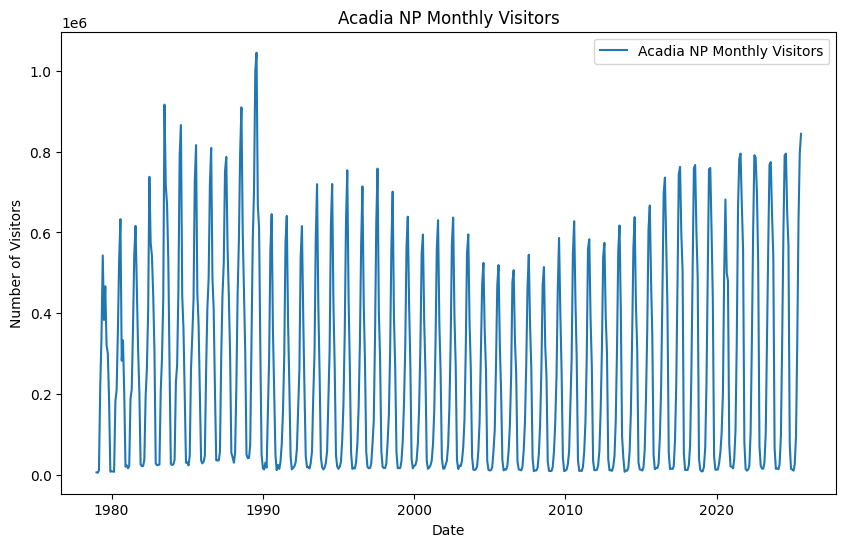

In [11]:
acadia = df[df["ParkName"] == "Acadia NP"].copy()

plt.figure(figsize=(10, 6))
plt.plot(acadia['Date'], acadia['RecreationVisits'], label='Acadia NP Monthly Visitors')
plt.title('Acadia NP Monthly Visitors')
plt.xlabel('Date')
plt.ylabel('Number of Visitors')
plt.legend()
plt.show()

In [12]:
acadia.head()

,ParkName,UnitCode,ParkType,Region,State,Year,Month,RecreationVisits,NonRecreationVisits,RecreationHours,NonRecreationHours,ConcessionerLodging,ConcessionerCamping,TentCampers,RVCampers,Backcountry,NonRecreationOvernightStays,MiscellaneousOvernightStays,Date
0,Acadia NP,ACAD,National Park,Northeast,ME,1979,January,6011.0,15252.0,37446.0,15252.0,0.0,0.0,102.0,13.0,0.0,0.0,0.0,1979-01-01
1,Acadia NP,ACAD,National Park,Northeast,ME,1979,February,5243.0,13776.0,17661.0,13776.0,0.0,0.0,53.0,8.0,0.0,0.0,0.0,1979-02-01
2,Acadia NP,ACAD,National Park,Northeast,ME,1979,March,11165.0,15252.0,36051.0,15252.0,0.0,0.0,176.0,37.0,0.0,0.0,0.0,1979-03-01
3,Acadia NP,ACAD,National Park,Northeast,ME,1979,April,219351.0,37657.0,1334058.0,37657.0,0.0,0.0,1037.0,459.0,0.0,0.0,0.0,1979-04-01
4,Acadia NP,ACAD,National Park,Northeast,ME,1979,May,339416.0,50616.0,2088588.0,50616.0,0.0,0.0,3193.0,1148.0,0.0,0.0,0.0,1979-05-01


In [13]:
acadia['MonthIndex'] = acadia.index
acadia['MonthIndex'] = acadia['Date'].map(pd.Timestamp.toordinal)

In [14]:
acadia.head()

,ParkName,UnitCode,ParkType,Region,State,Year,Month,RecreationVisits,NonRecreationVisits,RecreationHours,NonRecreationHours,ConcessionerLodging,ConcessionerCamping,TentCampers,RVCampers,Backcountry,NonRecreationOvernightStays,MiscellaneousOvernightStays,Date,MonthIndex
0,Acadia NP,ACAD,National Park,Northeast,ME,1979,January,6011.0,15252.0,37446.0,15252.0,0.0,0.0,102.0,13.0,0.0,0.0,0.0,1979-01-01,722450
1,Acadia NP,ACAD,National Park,Northeast,ME,1979,February,5243.0,13776.0,17661.0,13776.0,0.0,0.0,53.0,8.0,0.0,0.0,0.0,1979-02-01,722481
2,Acadia NP,ACAD,National Park,Northeast,ME,1979,March,11165.0,15252.0,36051.0,15252.0,0.0,0.0,176.0,37.0,0.0,0.0,0.0,1979-03-01,722509
3,Acadia NP,ACAD,National Park,Northeast,ME,1979,April,219351.0,37657.0,1334058.0,37657.0,0.0,0.0,1037.0,459.0,0.0,0.0,0.0,1979-04-01,722540
4,Acadia NP,ACAD,National Park,Northeast,ME,1979,May,339416.0,50616.0,2088588.0,50616.0,0.0,0.0,3193.0,1148.0,0.0,0.0,0.0,1979-05-01,722570


In [15]:
X = acadia[['MonthIndex']]
y = acadia['RecreationVisits']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [16]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
y_pred = model.predict(X_test)

In [18]:
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 115351599521.74757


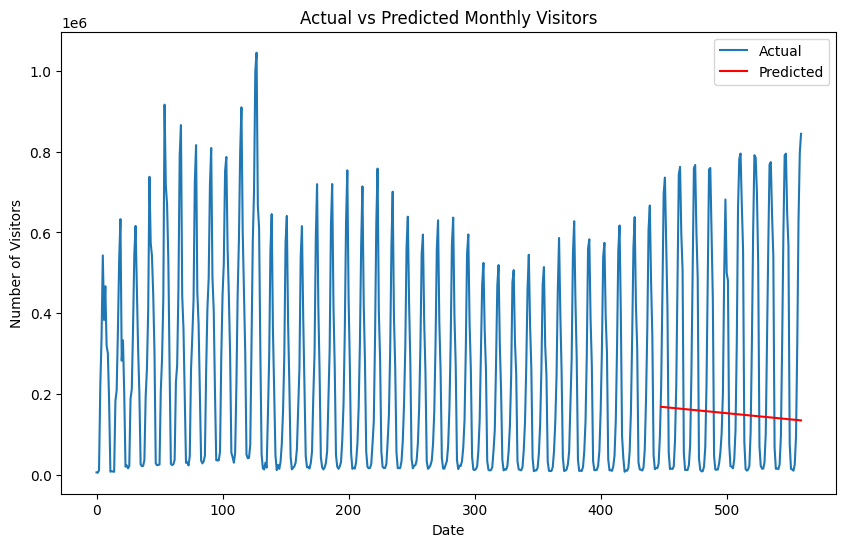

In [20]:
plt.figure(figsize=(10, 6))
plt.plot(acadia.index, acadia['RecreationVisits'], label='Actual')
plt.plot(X_test.index, y_pred, label='Predicted', color='red')
plt.title('Actual vs Predicted Monthly Visitors')
plt.xlabel('Date')
plt.ylabel('Number of Visitors')
plt.legend()
plt.show()